# Aula 17|: Neural ODEs e PINNs



## Codigo para Completar

In [ ]:
!pip install torchdiffeq

In [ ]:
# -*- coding: utf-8 -*-
"""
Aula 16: Laboratório Prático de Neural ODEs e PINNs
Versão com exercícios a completar.
"""

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from functools import partial

# --- PyTorch para comparação de Autodiff Reverso vs Adjunto ---
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchdiffeq import odeint_adjoint, odeint  # Necessário 'pip install torchdiffeq'

# --- JAX para PINNs (Diferenciação Automática de Alta Ordem) ---
try:
    import jax
    import jax.numpy as jnp
    from jax import grad, jit, vmap
    import optax  # Otimizador JAX
    print("JAX e OPTAX importados com sucesso.")
    JAX_AVAILABLE = True
except ImportError:
    print("JAX/Optax não encontrado. A Etapa 4 (PINN) não será executada.")
    JAX_AVAILABLE = False


# Configurações
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {DEVICE}")


JAX e OPTAX importados com sucesso.
Usando dispositivo: cuda:0


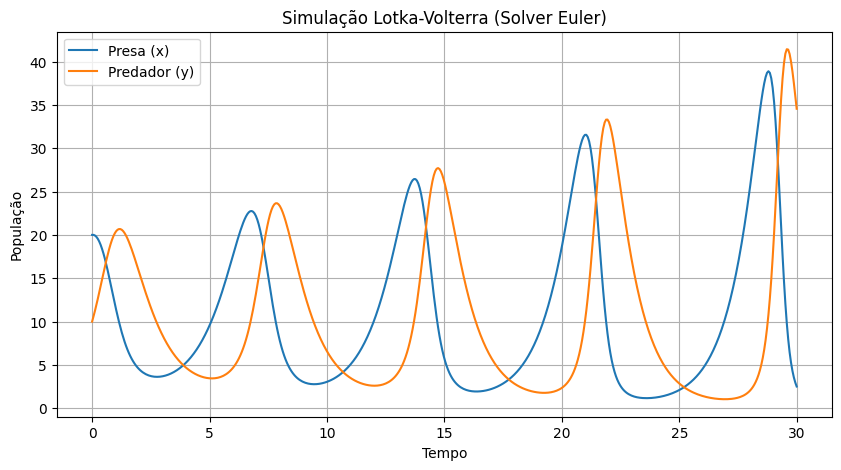

Etapa 1 concluída (quando você implementar o Euler!).


In [ ]:
# ===================================================================
# SETUP INICIAL: DEFINIÇÃO DE SISTEMAS (Sistemas Físicos/Ecológicos)
# ===================================================================

class LotkaVolterra(nn.Module):
    """
    Campo vetorial F(H, t) para o sistema Presa-Predador.
    """
    def __init__(self, alpha=1.0, beta=0.1, delta=0.1, gamma=1.0):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.delta = delta
        self.gamma = gamma

    def forward(self, t, h):
        x = h[:, 0]
        y = h[:, 1]
        dxdt = self.alpha * x - self.beta * x * y
        dydt = self.delta * x * y - self.gamma * y
        return torch.stack([dxdt, dydt], dim=1)


class DynamicsModel(nn.Module):
    """
    Campo vetorial neural f(H, t) (Neural ODE).
    """
    def __init__(self, hidden_dim):
        super(DynamicsModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim + 1, hidden_dim * 2),
            nn.Tanh(),
            nn.Linear(hidden_dim * 2, hidden_dim)
        )

    def forward(self, t, h):
        t_vec = torch.ones_like(h[:, :1]) * t
        x = torch.cat([h, t_vec], dim=1)
        return self.net(x)


HIDDEN_DIM = 2
BATCH_SIZE = 32
T_SPAN_TRAIN = torch.linspace(0., 1., 100).to(DEVICE)

H0 = torch.randn(BATCH_SIZE, HIDDEN_DIM).to(DEVICE)
TRUE_OUTPUT = torch.randn(BATCH_SIZE, HIDDEN_DIM).to(DEVICE)
F_NEURAL = DynamicsModel(HIDDEN_DIM).to(DEVICE)

# ===================================================================
# ETAPA 1: SOLVER CLÁSSICO (NUMPY/PYTHON) - Para Completar
# ===================================================================

def numpy_euler_solver(func, h0, t_span):
    """
    EXERCÍCIO 1.1: Implementar o Solver de Euler em Numpy.
    """
    h = h0.copy()
    dt = t_span[1] - t_span[0]
    trajectory = [h0.copy()]
    for t_idx in range(len(t_span) - 1):
        t_curr = t_span[t_idx]
        # TODO: implementar passo de Euler
        # f_val = func(h, t_curr)
        # h = h + dt * f_val
        f_val = func(h, t_curr)
        h = h + dt * f_val
        trajectory.append(h.copy())
    return np.array(trajectory)


def lotka_volterra_numpy(h, t):
    """
    EXERCÍCIO 1.2: adaptar parâmetros (alpha, beta, delta, gamma) e observar dinâmica.
    """
    alpha, beta, delta, gamma = 1.0, 0.1, 0.1, 1.0
    x, y = h[0], h[1]
    dxdt = alpha * x - beta * x * y
    dydt = delta * x * y - gamma * y
    return np.array([dxdt, dydt])


H0_LV = np.array([20.0, 10.0])
T_SPAN_LV = np.linspace(0., 30., 500)

lv_trajectory = numpy_euler_solver(lotka_volterra_numpy, H0_LV, T_SPAN_LV)

plt.figure(figsize=(10, 5))
plt.plot(T_SPAN_LV, lv_trajectory[:, 0], label='Presa (x)')
plt.plot(T_SPAN_LV, lv_trajectory[:, 1], label='Predador (y)')
plt.title('Simulação Lotka-Volterra (Solver Euler)')
plt.xlabel('Tempo')
plt.ylabel('População')
plt.legend()
plt.grid(True)
plt.show()

print("Etapa 1 concluída (quando você implementar o Euler!).")

In [ ]:


# ===================================================================
# ETAPA 2 & 3: PYTORCH - COMPARANDO O(L) vs O(1)
# ===================================================================

print("\n--- ETAPA 2 & 3: Comparação de Autodiff (PyTorch) ---")

def compare_autodiff(F_model, H0, T_span, true_output):
    # EXERCÍCIO 2.1: Autodiff Reverso Padrão (O(L))
    # TODO: usar odeint(F_model, H0, T_span, method='dopri5') e pegar o último estado

    H_TRAJ_STD = odeint(F_model, H0, T_span, method='dopri5')
    H_FINAL_STD = H_TRAJ_STD[-1]
    LOSS_STD = F.mse_loss(H_FINAL_STD, true_output)
    optimizer_std = optim.Adam(F_model.parameters(), lr=0.01)
    optimizer_std.zero_grad()
    LOSS_STD.backward()
    grad_norm_std = sum(p.grad.norm().item() for p in F_model.parameters() if p.grad is not None)
    print(f"  Padrão (O(L)): Loss={LOSS_STD.item():.6f}, Gradiente={grad_norm_std:.4f}")


    H_FINAL_ADJ = odeint_adjoint(F_model, H0, T_span, method='dopri5')
    H_FINAL_ADJ = H_FINAL_ADJ[-1]
    LOSS_ADJ = F.mse_loss(H_FINAL_ADJ, true_output)
    optimizer_adj = optim.Adam(F_model.parameters(), lr=0.01)
    optimizer_adj.zero_grad()
    LOSS_ADJ.backward()
    grad_norm_adj = sum(p.grad.norm().item() for p in F_model.parameters() if p.grad is not None)
    print(f"  Adjunto (O(1)): Loss={LOSS_ADJ.item():.6f}, Gradiente={grad_norm_adj:.4f}")


compare_autodiff(F_NEURAL, H0, T_SPAN_TRAIN, TRUE_OUTPUT)



--- ETAPA 2 & 3: Comparação de Autodiff (PyTorch) ---
  Padrão (O(L)): Loss=1.774195, Gradiente=1.8681
  Adjunto (O(1)): Loss=1.774195, Gradiente=1.8681


In [ ]:


# ===================================================================
# ETAPA 4: PINNs (JAX) - Para Completar
# ===================================================================

if JAX_AVAILABLE:
    print("\n--- ETAPA 4: PINNs (JAX) ---")

    def init_mlp(rng_key, layer_sizes):
        def initialize(key, in_dim, out_dim):
            return jax.random.normal(key, (in_dim, out_dim)) * jnp.sqrt(2 / in_dim)
        keys = jax.random.split(rng_key, len(layer_sizes) - 1)
        params = []
        for key, n_in, n_out in zip(keys, layer_sizes[:-1], layer_sizes[1:]):
            W = initialize(key, n_in, n_out)
            b = jnp.zeros(n_out)
            params.append((W, b))
        return params

    @jit
    def mlp_forward(params, x):
        x = jnp.atleast_2d(x)
        for W, b in params[:-1]:
            x = jnp.dot(x, W) + b
            x = jnp.tanh(x)
        W, b = params[-1]
        x = jnp.dot(x, W) + b
        return x.squeeze()

    @jit
    def pde_residual(params, x, t, nu):
        def u_hat(x_, t_):
            return mlp_forward(params, jnp.array([x_, t_]))

        def u_t_1(t_):
            return u_hat(x,t_)

        def u_x_1(x_):
            return u_hat(x_,t)


        u_t = grad(u_t_1)(t) #grad(lambda tt: u_hat(x, tt))(t)
        u_x = grad(u_x_1)
        u_xx = grad(u_x)(x)  #grad(lambda xx: grad(lambda xx2: u_hat(xx2, t))(xx))(x)
        return u_t - nu * u_xx

    @jit
    def pinn_loss(params, batch_domain, nu, boundary_y, boundary_x, boundary_t):
        u_boundary_pred = vmap(lambda x, t: mlp_forward(params, jnp.array([x, t])))(boundary_x, boundary_t)
        loss_boundary = jnp.mean((u_boundary_pred - boundary_y)**2)
        residual_preds = vmap(lambda x, t: pde_residual(params, x, t, nu))(batch_domain[:, 0], batch_domain[:, 1])
        loss_fisica = jnp.mean(residual_preds**2)
        return loss_boundary + loss_fisica

    print("PINN configurado. Complete os TODOs para treinar o modelo.")


    rng = jax.random.PRNGKey(0)
    LAYER_SIZES = [2, 20, 20, 1]
    MLP_PARAMS = init_mlp(rng, LAYER_SIZES)
    NU_CONST = 0.01

    NUM_POINTS = 1000
    X_DOMAIN = jax.random.uniform(rng, (NUM_POINTS,), minval=-1.0, maxval=1.0)
    T_DOMAIN = jax.random.uniform(rng, (NUM_POINTS,), minval=0.0, maxval=1.0)
    DOMAIN_DATA = jnp.stack([X_DOMAIN, T_DOMAIN], axis=1)

    X_BOUNDARY = jnp.linspace(-1.0, 1.0, 50)
    T_BOUNDARY = jnp.zeros_like(X_BOUNDARY)
    U_BOUNDARY_TRUE = jnp.sin(jnp.pi * X_BOUNDARY)

    optimizer_pinn = optax.adam(learning_rate=0.001)

    @jit
    def update_pinn_step(params, opt_state):
        loss_val, grads = jax.value_and_grad(pinn_loss)(
            params, DOMAIN_DATA, NU_CONST, U_BOUNDARY_TRUE, X_BOUNDARY, T_BOUNDARY
        )
        updates, opt_state = optimizer_pinn.update(grads, opt_state, params)
        new_params = optax.apply_updates(params, updates)
        return loss_val, new_params, opt_state

    print("\n--- Treinamento PINN em JAX (100 passos) ---")
    optimizer_state = optimizer_pinn.init(MLP_PARAMS)
    for step in tqdm(range(2000)):
        loss_val, MLP_PARAMS, optimizer_state = update_pinn_step(MLP_PARAMS, optimizer_state)
        if step % 20 == 0:
            print(f"Passo {step}: Custo Total PINN = {loss_val:.6f}")

    print("Treinamento PINN concluído.")



--- ETAPA 4: PINNs (JAX) ---
PINN configurado. Complete os TODOs para treinar o modelo.

--- Treinamento PINN em JAX (100 passos) ---


  0%|          | 0/2000 [00:00<?, ?it/s]

Passo 0: Custo Total PINN = 1.079295
Passo 20: Custo Total PINN = 0.241463
Passo 40: Custo Total PINN = 0.184307
Passo 60: Custo Total PINN = 0.149297
Passo 80: Custo Total PINN = 0.128549
Passo 100: Custo Total PINN = 0.113458
Passo 120: Custo Total PINN = 0.100478
Passo 140: Custo Total PINN = 0.088708
Passo 160: Custo Total PINN = 0.078035
Passo 180: Custo Total PINN = 0.068550
Passo 200: Custo Total PINN = 0.060341
Passo 220: Custo Total PINN = 0.053416
Passo 240: Custo Total PINN = 0.047701
Passo 260: Custo Total PINN = 0.043060
Passo 280: Custo Total PINN = 0.039326
Passo 300: Custo Total PINN = 0.036325
Passo 320: Custo Total PINN = 0.033895
Passo 340: Custo Total PINN = 0.031895
Passo 360: Custo Total PINN = 0.030210
Passo 380: Custo Total PINN = 0.028749
Passo 400: Custo Total PINN = 0.027447
Passo 420: Custo Total PINN = 0.026259
Passo 440: Custo Total PINN = 0.025151
Passo 460: Custo Total PINN = 0.024105
Passo 480: Custo Total PINN = 0.023106
Passo 500: Custo Total PINN = 0

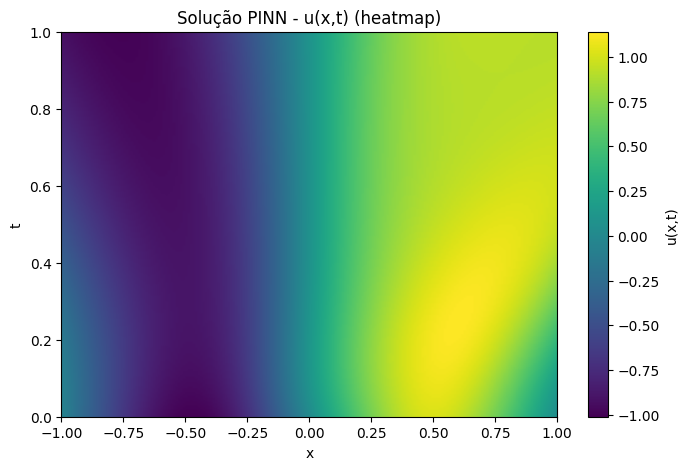

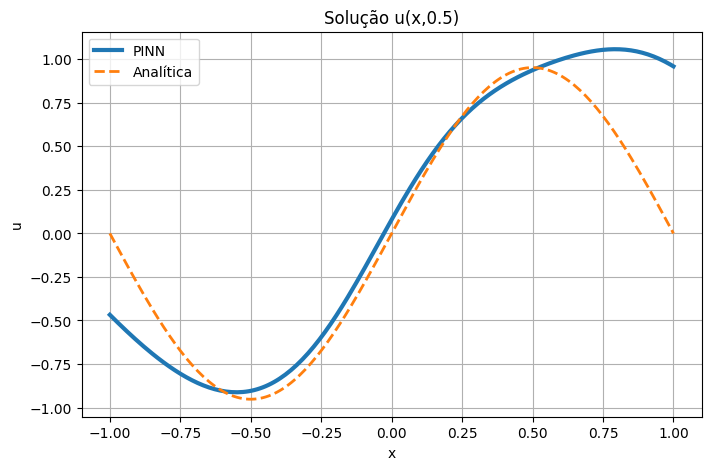

In [ ]:
# ===================================================================
# Função de visualização para PINN
# ===================================================================

import matplotlib.pyplot as plt

def visualize_pinn_solution(params, nu, x_min=-1.0, x_max=1.0, t_min=0.0, t_max=1.0,
                            Nx=200, Nt=200, analytic=True):
    """
    Visualiza a solução aprendida pela PINN.

    Params:
        params: parâmetros da rede treinada
        nu: coeficiente de difusão
        analytic: se True, plota solução analítica u(x,t) = exp(-(pi^2)*nu*t)*sin(pi*x)
    """

    # Grade espaço–tempo
    x_vals = jnp.linspace(x_min, x_max, Nx)
    t_vals = jnp.linspace(t_min, t_max, Nt)

    # Avaliar rede na grade
    u_pred = jnp.zeros((Nx, Nt))

    for i, x in enumerate(x_vals):
        for j, t in enumerate(t_vals):
            u_pred = u_pred.at[i, j].set(mlp_forward(params, jnp.array([x, t])))

    # Solução analítica opcional
    if analytic:
        u_true = jnp.zeros_like(u_pred)
        for i, x in enumerate(x_vals):
            for j, t in enumerate(t_vals):
                u_true = u_true.at[i, j].set(jnp.exp(-(jnp.pi**2)*nu*t) * jnp.sin(jnp.pi*x))

    # ---------- Plot 1: heatmap ----------
    plt.figure(figsize=(8, 5))
    plt.imshow(u_pred.T, origin="lower", extent=[x_min, x_max, t_min, t_max], aspect="auto")
    plt.colorbar(label="u(x,t)")
    plt.title("Solução PINN - u(x,t) (heatmap)")
    plt.xlabel("x")
    plt.ylabel("t")
    plt.show()

    # ---------- Plot 2: comparação em t fixo ----------
    t_show = 0.5  # tempo escolhido para comparação
    j = int((t_show - t_min) / (t_max - t_min) * (Nt - 1))

    plt.figure(figsize=(8, 5))
    plt.plot(x_vals, u_pred[:, j], label="PINN", lw=3)
    if analytic:
        plt.plot(x_vals, u_true[:, j], "--", label="Analítica", lw=2)
    plt.title(f"Solução u(x,{t_show})")
    plt.xlabel("x")
    plt.ylabel("u")
    plt.grid(True)
    plt.legend()
    plt.show()
visualize_pinn_solution(MLP_PARAMS, NU_CONST)

In [ ]:
# ================================================================
# SEÇÃO: Treinar F_NEURAL para aproximar o sistema Lotka–Volterra
# ================================================================

# Campo vetorial "verdadeiro": Lotka–Volterra com parâmetros fixos
TRUE_LV = LotkaVolterra(alpha=1.0, beta=0.1, delta=0.1, gamma=1.0).to(DEVICE)

# Grade de tempo para treinamento
T_TRAIN_LV = torch.linspace(0., 20., 200).to(DEVICE)  # 20 unidades de tempo, 200 pontos

# Otimizador para a Neural ODE
optimizer_lv = optim.Adam(F_NEURAL.parameters(), lr=1)

# Número de condições iniciais aleatórias por batch
N_IC = 32

EPOCHS = 1000  # pode aumentar/diminuir dependendo do tempo de laboratório

for epoch in range(EPOCHS):
    # Amostra condições iniciais no quadrante positivo
    H0_batch = torch.rand(N_IC, 2, device=DEVICE) * 20.0  # [N_IC, 2]

    # Trajetória verdadeira (Lotka–Volterra)
    with torch.no_grad():
        true_traj = odeint(TRUE_LV, H0_batch, T_TRAIN_LV, method='dopri5')  # [T, N_IC, 2]

    # Trajetória da Neural ODE
    pred_traj = odeint(F_NEURAL, H0_batch, T_TRAIN_LV, method='dopri5')     # [T, N_IC, 2]

    # Loss MSE entre as trajetórias
    loss = F.mse_loss(pred_traj, true_traj)

    optimizer_lv.zero_grad()
    loss.backward()
    optimizer_lv.step()

    if epoch % 50 == 0:
        print(f"[Treino LV] Época {epoch:03d} | Loss = {loss.item():.6f}")

[Treino LV] Época 000 | Loss = 93.641708


KeyboardInterrupt: 

In [ ]:
# ================================================================
# SEÇÃO: Comparação entre a dinâmica verdadeira e a rede aprendida
# ================================================================

import matplotlib.pyplot as plt

# Condição inicial para avaliação
H0_eval = torch.tensor([[20.0, 10.0]], device=DEVICE)  # [1, 2]

# Grade de tempo para visualização
T_VIS = torch.linspace(0., 30., 300).to(DEVICE)

with torch.no_grad():
    # Trajetória verdadeira (Lotka–Volterra)
    true_traj = odeint(TRUE_LV, H0_eval, T_VIS, method='dopri5')  # [T, 1, 2]
    # Trajetória da Neural ODE aprendida
    pred_traj = odeint(F_NEURAL, H0_eval, T_VIS, method='dopri5')

true_traj = true_traj.cpu().numpy()[:, 0, :]  # [T, 2]
pred_traj = pred_traj.cpu().numpy()[:, 0, :]  # [T, 2]
t_vis = T_VIS.cpu().numpy()

# ---------- Plot 1: populações vs tempo ----------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(t_vis, true_traj[:, 0], label='Presa (verdadeiro)', linewidth=2)
plt.plot(t_vis, true_traj[:, 1], label='Predador (verdadeiro)', linewidth=2)
plt.plot(t_vis, pred_traj[:, 0], '--', label='Presa (Neural ODE)', linewidth=2)
plt.plot(t_vis, pred_traj[:, 1], '--', label='Predador (Neural ODE)', linewidth=2)
plt.xlabel('Tempo')
plt.ylabel('População')
plt.title('População vs Tempo')
plt.legend()
plt.grid(True)

# ---------- Plot 2: plano de fases x vs y ----------
plt.subplot(1, 2, 2)
plt.plot(true_traj[:, 0], true_traj[:, 1], label='LV verdadeiro', linewidth=2)
plt.plot(pred_traj[:, 0], pred_traj[:, 1], '--', label='Neural ODE', linewidth=2)
plt.xlabel('Presa (x)')
plt.ylabel('Predador (y)')
plt.title('Plano de fases')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
